In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuración inicial
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SEGUNDA PRUEBA (cáncer de pulmón)



In [ ]:
# Cargar conjunto de test nuevo
test_dataset = ImageFolder(root="/content/drive/MyDrive/dataset/val", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


In [ ]:
# Ruta donde están guardados los modelos
save_dir = "/content/drive/MyDrive/modelos_ensamblados"

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 2
BATCH_SIZE = 32

In [ ]:
# Función para cargar modelo y adaptar capa final
def load_model(model_fn, weight_path):
    model = model_fn(pretrained=False)
    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

In [ ]:
import torchvision.models as tv_models  # Usa un alias para evitar conflicto con tu variable `models`
import os

save_dir = "/content/drive/MyDrive/modelos_ensamblados"  # Reemplaza con la ruta correcta

# Carga de modelos
resnet50 = load_model(tv_models.resnet50, os.path.join(save_dir, "resnet50.pth")) # Se cambió models a tv_models
efficientnet_b0 = load_model(tv_models.efficientnet_b0, os.path.join(save_dir, "efficientnet_b0.pth")) # Se cambió models a tv_models
regnet_y_400mf = load_model(tv_models.regnet_y_400mf, os.path.join(save_dir, "regnet_y_400mf.pth")) # Se cambió models a tv_models


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# Ensamblado por votación mayoritaria
def ensemble_predict_with_votes(models, dataloader):
    all_votes = []
    true_labels = []

    for model in models:
        model.eval()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # Obtener predicciones de cada modelo
            outputs = [model(inputs).cpu().numpy() for model in models]
            preds = [output.argmax(axis=1) for output in outputs]

            # Votación mayoritaria
            final_preds = [Counter([pred[i] for pred in preds]).most_common(1)[0][0] for i in range(len(preds[0]))]

            # Guardar las votaciones de cada modelo para cada imagen
            for i in range(len(final_preds)):
                votes = {f"Modelo_{j+1}": preds[j][i] for j in range(len(models))}
                votes["Votación_Mayoritaria"] = final_preds[i]
                votes["Etiqueta_Real"] = labels[i].item()
                all_votes.append(votes)

            true_labels.extend(labels.cpu().numpy())

    return all_votes, true_labels

In [ ]:
# Paso 4: Evaluar el modelo ensamblado y generar métricas
models = [resnet50, efficientnet_b0, regnet_y_400mf]

# Evaluar el modelo ensamblado con votaciones
votes, true_labels = ensemble_predict_with_votes(models, test_loader)

# Convertir las votaciones a un DataFrame
votes_df = pd.DataFrame(votes)
print("\nTabla de votaciones para las 750 imágenes:")
print(votes_df)

# Calcular métricas para el modelo ensamblado
ensemble_preds = votes_df["Votación_Mayoritaria"].values
accuracy = accuracy_score(true_labels, ensemble_preds)
precision = precision_score(true_labels, ensemble_preds, average='macro', zero_division=0)
recall = recall_score(true_labels, ensemble_preds, average='macro', zero_division=0)
f1 = f1_score(true_labels, ensemble_preds, average='macro', zero_division=0)

print("\nMétricas del modelo ensamblado:")
print(f"Precisión: {accuracy:.4f}")
print(f"Precisión Macro: {precision:.4f}")
print(f"Recall Macro: {recall:.4f}")
print(f"F1-Score Macro: {f1:.4f}")


Tabla de votaciones para las 750 imágenes:
      Modelo_1  Modelo_2  Modelo_3  Votación_Mayoritaria  Etiqueta_Real
0            0         0         0                     0              0
1            0         0         0                     0              0
2            0         0         0                     0              0
3            0         0         0                     0              0
4            0         0         0                     0              0
...        ...       ...       ...                   ...            ...
1495         0         0         0                     0              1
1496         0         0         0                     0              1
1497         0         0         0                     0              1
1498         0         0         0                     0              1
1499         0         0         0                     0              1

[1500 rows x 5 columns]

Métricas del modelo ensamblado:
Precisión: 0.5000
Precisión Macro:


Matriz de confusión del modelo ensamblado:


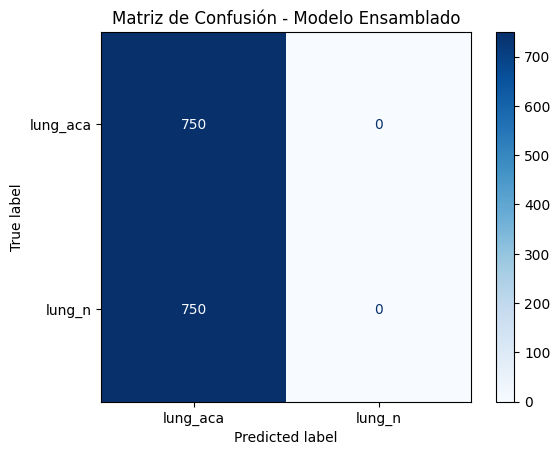

In [ ]:
# Paso 5: Mostrar matriz de confusión para el modelo ensamblado
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

print("\nMatriz de confusión del modelo ensamblado:")
plot_confusion_matrix(true_labels, ensemble_preds, "Matriz de Confusión - Modelo Ensamblado")

# TERCERA PRUEBA (cáncer de seno)

In [ ]:
# Cargar conjunto de test nuevo
test_dataset = ImageFolder(root="/content/drive/MyDrive/dataset2/val", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
# Ruta donde están guardados los modelos
save_dir = "/content/drive/MyDrive/modelos_ensamblados"

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 2
BATCH_SIZE = 32

In [ ]:
# Función para cargar modelo y adaptar capa final
def load_model(model_fn, weight_path):
    model = model_fn(pretrained=False)
    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

In [ ]:
import torchvision.models as tv_models  # Usa un alias para evitar conflicto con la variable `models`
import os

save_dir = "/content/drive/MyDrive/modelos_ensamblados"  # Reemplaza con la ruta correcta

# Carga de modelos
resnet50 = load_model(tv_models.resnet50, os.path.join(save_dir, "resnet50.pth")) # Se cambió models a tv_models
efficientnet_b0 = load_model(tv_models.efficientnet_b0, os.path.join(save_dir, "efficientnet_b0.pth")) # Se cambió models a tv_models
regnet_y_400mf = load_model(tv_models.regnet_y_400mf, os.path.join(save_dir, "regnet_y_400mf.pth")) # Se cambió models a tv_models

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# Ensamblado por votación mayoritaria
def ensemble_predict_with_votes(models, dataloader):
    all_votes = []
    true_labels = []

    for model in models:
        model.eval()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # Obtener predicciones de cada modelo
            outputs = [model(inputs).cpu().numpy() for model in models]
            preds = [output.argmax(axis=1) for output in outputs]

            # Votación mayoritaria
            final_preds = [Counter([pred[i] for pred in preds]).most_common(1)[0][0] for i in range(len(preds[0]))]

            # Guardar las votaciones de cada modelo para cada imagen
            for i in range(len(final_preds)):
                votes = {f"Modelo_{j+1}": preds[j][i] for j in range(len(models))}
                votes["Votación_Mayoritaria"] = final_preds[i]
                votes["Etiqueta_Real"] = labels[i].item()
                all_votes.append(votes)

            true_labels.extend(labels.cpu().numpy())

    return all_votes, true_labels

In [ ]:
# Evaluar el modelo ensamblado y generar métricas
models = [resnet50, efficientnet_b0, regnet_y_400mf]

# Evaluar el modelo ensamblado con votaciones
votes, true_labels = ensemble_predict_with_votes(models, test_loader)

# Convertir las votaciones a un DataFrame
votes_df = pd.DataFrame(votes)
print("\nTabla de votaciones para las 2000 imágenes:")
print(votes_df)

# Calcular métricas para el modelo ensamblado
ensemble_preds = votes_df["Votación_Mayoritaria"].values
accuracy = accuracy_score(true_labels, ensemble_preds)
precision = precision_score(true_labels, ensemble_preds, average='macro', zero_division=0)
recall = recall_score(true_labels, ensemble_preds, average='macro', zero_division=0)
f1 = f1_score(true_labels, ensemble_preds, average='macro', zero_division=0)

print("\nMétricas del modelo ensamblado:")
print(f"Precisión: {accuracy:.4f}")
print(f"Precisión Macro: {precision:.4f}")
print(f"Recall Macro: {recall:.4f}")
print(f"F1-Score Macro: {f1:.4f}")


Tabla de votaciones para las 2000 imágenes:
      Modelo_1  Modelo_2  Modelo_3  Votación_Mayoritaria  Etiqueta_Real
0            0         0         0                     0              0
1            0         1         0                     0              0
2            0         0         0                     0              0
3            0         1         0                     0              0
4            0         0         0                     0              0
...        ...       ...       ...                   ...            ...
1995         0         0         0                     0              1
1996         0         1         0                     0              1
1997         0         1         0                     0              1
1998         0         0         0                     0              1
1999         0         0         0                     0              1

[2000 rows x 5 columns]

Métricas del modelo ensamblado:
Precisión: 0.5000
Precisión Macro


Matriz de confusión del modelo ensamblado:


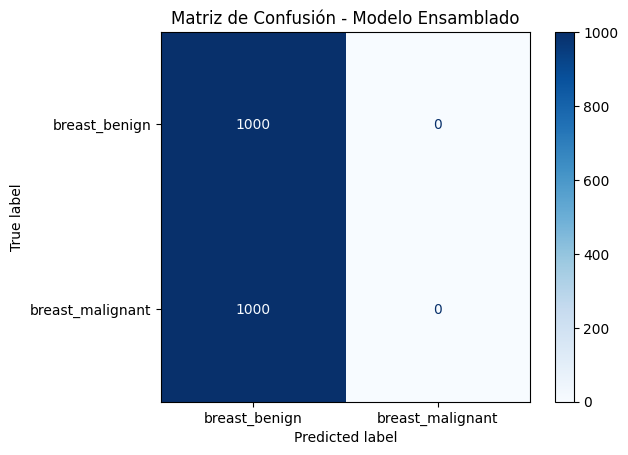

In [ ]:
# Paso 5: Mostrar matriz de confusión para el modelo ensamblado
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

print("\nMatriz de confusión del modelo ensamblado:")
plot_confusion_matrix(true_labels, ensemble_preds, "Matriz de Confusión - Modelo Ensamblado")